In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#GLOBAL SETTINGS

sns.set_theme(
style="whitegrid",
palette="Set2"
)

plt.rcParams["figure.figsize"] = (12,6)

plt.rcParams["figure.dpi"] = 120

In [ ]:
df = pd.read_csv("C:/Users/riya/OneDrive/project/Disease-Outbreak-Prediction-Platform/data/processed_data.csv")

In [ ]:
df.columns = (
df.columns
.str.strip()
.str.lower()
)

In [ ]:
numeric_cols = [
"cases",
"deaths",
"temp",
"precipitation",
"lai",
"month",
"year"
]

for col in numeric_cols:

    df[col] = pd.to_numeric(
    df[col],
    errors="coerce"
    )

In [ ]:
print(df.shape)

print(df.dtypes)

df.head()

(8985, 17)
id                    int64
week_of_outbreak     object
state_ut             object
district             object
disease              object
cases               float64
deaths                int64
day                   int64
month                 int64
year                  int64
latitude            float64
longitude           float64
precipitation       float64
lai                 float64
temp                float64
disease_category     object
death_rate          float64
dtype: object


,id,week_of_outbreak,state_ut,district,disease,cases,deaths,day,month,year,latitude,longitude,precipitation,lai,temp,disease_category,death_rate
0,0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160.0,1,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333,Diarrheal Diseases,0.006211
1,1,2nd week,Maharashtra,Gadchiroli,Malaria,7.0,2,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000,Malaria,0.250000
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8.0,1,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667,Diarrheal Diseases,0.111111
3,3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7.0,1,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000,Diarrheal Diseases,0.125000
4,4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14.0,0,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000,Diarrheal Diseases,0.000000


In [ ]:
#SORT DATA

df = df.sort_values([
"state_ut",
"district",
"disease",
"year",
"month"
])

In [ ]:
#CREATE DATE COLUMN

df["date"] = pd.to_datetime(
df["year"].astype(int).astype(str) + "-" + df["month"].astype(int).astype(str) + "-01")

In [ ]:
#LAG FEATURES

lag_features = [1, 2, 3, 6, 12]
for lag in lag_features:

    df[f"lag_{lag}"] = (

    df.groupby(
        ["district", "disease"]
    )["cases"]

    .shift(lag)
    )
print("✅ Lag Features Created")

✅ Lag Features Created


In [ ]:
#ROLLING FEATURES
#LEAKAGE SAFE USING shift(1)

group = df.groupby(
["district", "disease"]
)["cases"]

#3 Month Rolling Mean

df["roll_3_mean"] = (

group.transform(
    lambda x:

    x.shift(1)
    .rolling(window=3)
    .mean()
))

#6 Month Rolling Mean

df["roll_6_mean"] = (

group.transform(
    lambda x:

    x.shift(1)
    .rolling(window=6)
    .mean()
))

#3 Month Rolling Std

df["roll_3_std"] = (

group.transform(
    lambda x:

    x.shift(1)
    .rolling(window=3)
    .std()
)

)

#6 Month Rolling Std

df["roll_6_std"] = (

group.transform(
    lambda x:

    x.shift(1)
    .rolling(window=6)
    .std()
)

)

print("✅ Rolling Features Created")

✅ Rolling Features Created


In [ ]:
#CYCLIC MONTH FEATURES

df["month_sin"] = np.sin(
2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
2 * np.pi * df["month"] / 12
)

print("✅ Cyclic Features Created")

✅ Cyclic Features Created


In [ ]:
#CLIMATE CHANGE FEATURES

climate_cols = [
"temp",
"precipitation",
"lai"
]

for col in climate_cols:

  df[f"{col}_change"] = (

    df.groupby(
        ["district"]
    )[col]

    .diff()
  )

print("✅ Climate Change Features Created")

✅ Climate Change Features Created


In [ ]:
# DEATH RATE FEATURE
df["death_rate"] = (

    df["deaths"]

    /

    (df["cases"] + 1)
)

print("✅ Death Rate Feature Created")

✅ Death Rate Feature Created


In [ ]:
#SPIKE RATIO

df["spike_ratio"] = (df["cases"] / (df["roll_3_mean"] + 1))

In [ ]:
#ACCELERATION FEATURE

df["acceleration"] = ( df["lag_1"] - df["lag_2"] )

In [ ]:
#GROWTH RATE

df["growth_rate"] = ( (df["lag_1"] - df["lag_3"]) / (df["lag_3"] + 1) )

In [ ]:
#OUTBREAK FREQUENCY

threshold = df["cases"].quantile(0.75)

df["outbreak_flag"] = (

df["cases"] > threshold

).astype(int)

df["outbreak_frequency_12m"] = (

df.groupby(
    ["district", "disease"]
)["outbreak_flag"]

.transform(

    lambda x:

    x.shift(1)
    .rolling(12)
    .sum()
)

)

print("✅ Outbreak Intelligence Features Created")

✅ Outbreak Intelligence Features Created


In [ ]:
#TARGET VARIABLES
#Regression Target

df["log_cases"] = np.log1p( df["cases"] )

#Classification Target

outbreak_threshold = df["cases"].quantile(0.75) 
df["outbreak"] = ( df["cases"] > outbreak_threshold ).astype(int)

print("✅ Target Variables Created")

✅ Target Variables Created


In [ ]:
#HANDLE GENERATED NaNs

feature_cols = [

"lag_1",
"lag_2",
"lag_3",
"lag_6",
"lag_12",

"roll_3_mean",
"roll_6_mean",

"roll_3_std",
"roll_6_std",

"temp_change",
"precipitation_change",
"lai_change",

"spike_ratio",
"acceleration",
"growth_rate",

"outbreak_frequency_12m"

]

df[feature_cols] = (
df[feature_cols]
.fillna(0)
)

print("✅ Missing Feature Values Filled")

✅ Missing Feature Values Filled


In [ ]:
#FEATURE VALIDATION

print("=" * 60)

print("Feature Engineering Validation")

print("=" * 60)

print(df[feature_cols].isnull().sum())

print("=" * 60)

Feature Engineering Validation
lag_1                     0
lag_2                     0
lag_3                     0
lag_6                     0
lag_12                    0
roll_3_mean               0
roll_6_mean               0
roll_3_std                0
roll_6_std                0
temp_change               0
precipitation_change      0
lai_change                0
spike_ratio               0
acceleration              0
growth_rate               0
outbreak_frequency_12m    0
dtype: int64


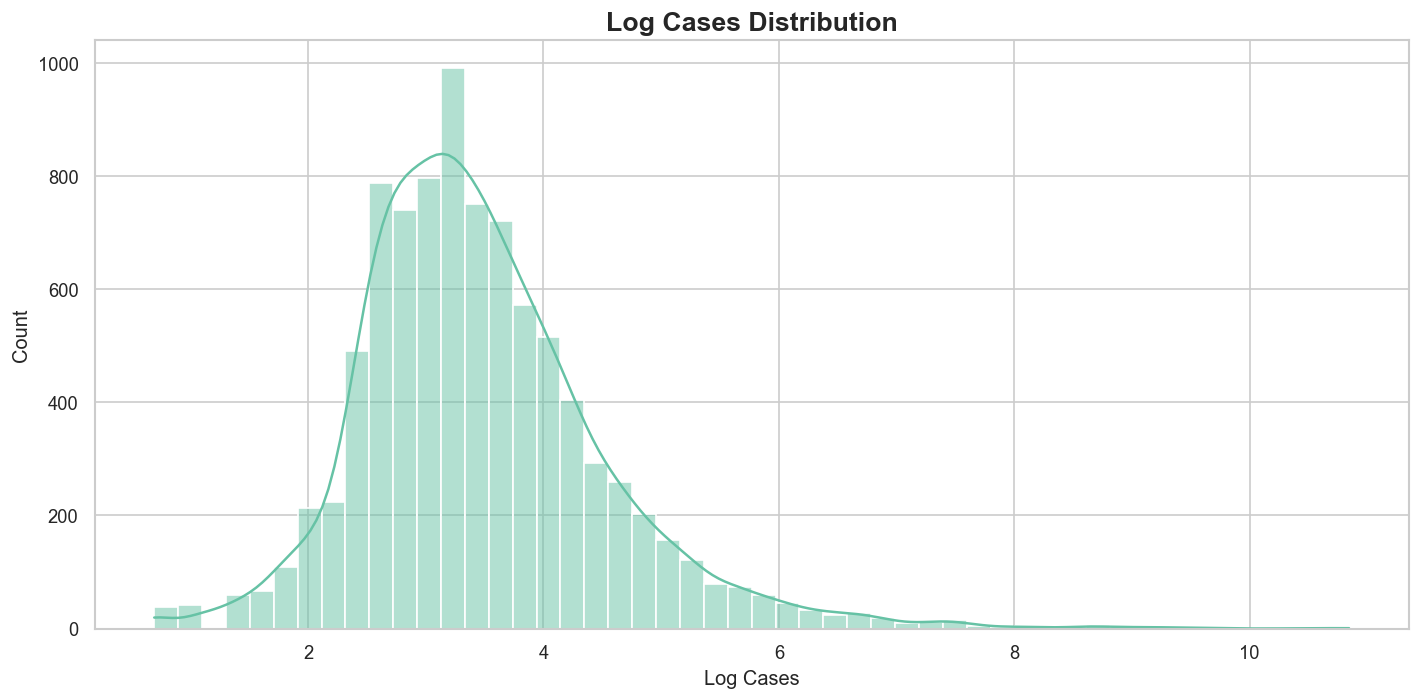

In [ ]:
#FEATURE DISTRIBUTIONS

plt.figure(figsize=(12,6))

sns.histplot(
df["log_cases"],
bins=50,
kde=True
)

plt.title(
"Log Cases Distribution",
fontsize=16,
fontweight="bold"
)

plt.xlabel("Log Cases")

plt.tight_layout()

plt.show()

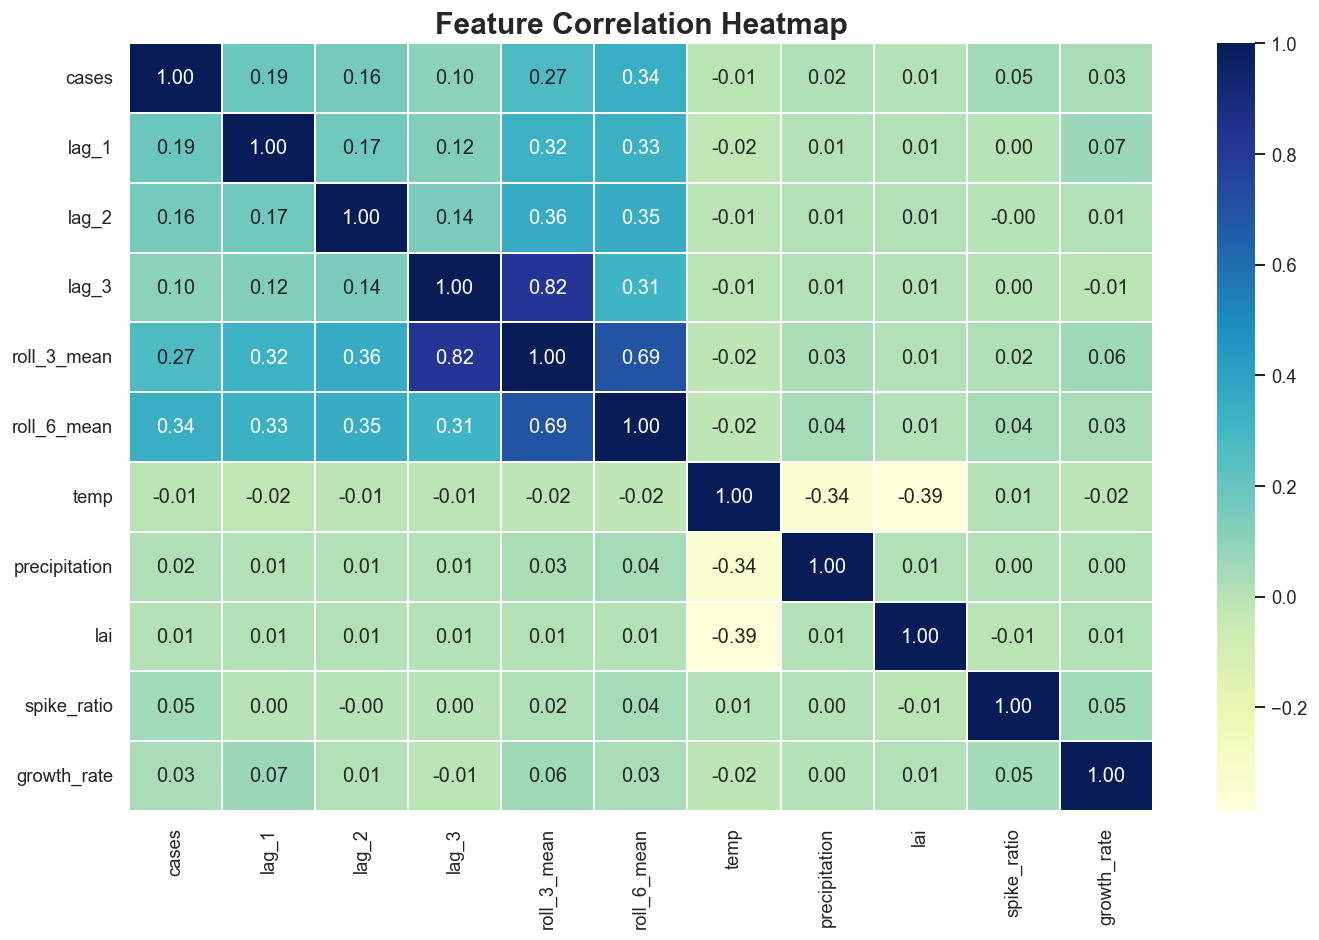

In [ ]:
#FEATURE CORRELATION

corr_cols = [
"cases",
"lag_1",
"lag_2",
"lag_3",
"roll_3_mean",
"roll_6_mean",
"temp",
"precipitation",
"lai",
"spike_ratio",
"growth_rate"
]
corr = (
df[corr_cols]
.corr()
)
plt.figure(figsize=(12,8))
sns.heatmap(
corr,
annot=True,
fmt=".2f",
cmap="YlGnBu",
linewidths=1,
linecolor="white"
)

plt.title(
"Feature Correlation Heatmap",
fontsize=18,
fontweight="bold"
)
plt.tight_layout()
plt.show()

In [ ]:
#REMOVE DUPLICATES

df = df.drop_duplicates()
print("✅ Duplicates Removed")

✅ Duplicates Removed


In [ ]:
#FINAL DATASET CHECK

print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head())
df.head()

(8985, 39)
log_cases      1
cases          1
death_rate     1
id             0
temp_change    0
dtype: int64


,id,week_of_outbreak,state_ut,district,disease,cases,deaths,day,month,year,...,temp_change,precipitation_change,lai_change,spike_ratio,acceleration,growth_rate,outbreak_flag,outbreak_frequency_12m,log_cases,outbreak
837,837,23rd week,Andaman and Nicobar Islands,Andaman,Acute Diarrhoeal Disease,8.0,1,6,6,2019,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,2.197225,0
1192,1192,41st week,Andaman and Nicobar Islands,Andaman,Acute Diarrhoeal Disease,30.0,1,9,10,2019,...,-2.813333,-0.622747,9.0,0.0,0.0,0.0,0,0.0,3.433987,0
6193,6193,51st week,Andaman and Nicobar Islands,North and Middle Andaman,Acute Diarrhoeal Disease,86.0,1,16,12,2013,...,0.000000,0.000000,0.0,0.0,0.0,0.0,1,0.0,4.465908,1
6526,6526,25th week,Andhra Pradesh,Anantapur,Acute Diarrhoeal Disease,23.0,0,26,6,2011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.178054,0
7342,7342,25th week,Andhra Pradesh,Anantapur,Acute Diarrhoeal Disease,23.0,0,26,6,2011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.178054,0


In [ ]:
df = df.dropna(
    subset=[
        "cases",
        "log_cases",
        "death_rate"
    ]
)

print("✅ Invalid Target Rows Removed")

✅ Invalid Target Rows Removed


In [ ]:
#FINAL DATASET CHECK

print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head())
df.head()

(8984, 39)
id             0
temp_change    0
lag_12         0
roll_3_mean    0
roll_6_mean    0
dtype: int64


,id,week_of_outbreak,state_ut,district,disease,cases,deaths,day,month,year,...,temp_change,precipitation_change,lai_change,spike_ratio,acceleration,growth_rate,outbreak_flag,outbreak_frequency_12m,log_cases,outbreak
837,837,23rd week,Andaman and Nicobar Islands,Andaman,Acute Diarrhoeal Disease,8.0,1,6,6,2019,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,2.197225,0
1192,1192,41st week,Andaman and Nicobar Islands,Andaman,Acute Diarrhoeal Disease,30.0,1,9,10,2019,...,-2.813333,-0.622747,9.0,0.0,0.0,0.0,0,0.0,3.433987,0
6193,6193,51st week,Andaman and Nicobar Islands,North and Middle Andaman,Acute Diarrhoeal Disease,86.0,1,16,12,2013,...,0.000000,0.000000,0.0,0.0,0.0,0.0,1,0.0,4.465908,1
6526,6526,25th week,Andhra Pradesh,Anantapur,Acute Diarrhoeal Disease,23.0,0,26,6,2011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.178054,0
7342,7342,25th week,Andhra Pradesh,Anantapur,Acute Diarrhoeal Disease,23.0,0,26,6,2011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,3.178054,0


In [ ]:
import os
os.makedirs("../data/final", exist_ok=True)

df.to_csv(
    "../data/final/ml_dataset.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!
